In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import ast

In [54]:
train = pd.read_excel("DeepX_train.xlsx")
val = pd.read_excel("DeepX_validation.xlsx")
test = pd.read_excel("DeepX_unlabeled.xlsx")

In [55]:
print(train.shape)
print(train.columns)
train.head()

(1971, 9)
Index(['review_id', 'review_text', 'star_rating', 'date', 'business_name',
       'business_category', 'platform', 'aspects', 'aspect_sentiments'],
      dtype='object')


,review_id,review_text,star_rating,date,business_name,business_category,platform,aspects,aspect_sentiments
0,7238,لا يوجد الدفع بالبطاقه عند الاستلام,3,2026-03-08 00:00:00,Noon,ecommerce,play_store,"[""app_experience"", ""delivery""]","{""app_experience"": ""negative"", ""delivery"": ""ne..."
1,1036,المكان نضيف وجميل وقعدته تحفه والخدمة فوق المم...,5,قبل يومين (2),ممشي مصر Mawlana Cafe,كافيه,google_maps,"[""cleanliness"", ""ambiance"", ""service""]","{""cleanliness"": ""positive"", ""ambiance"": ""posit..."
2,1975,تجربة سيئة سألتهم الاكل هياخد وقت قد ايه قالول...,1,قبل شهر,بيت لحم Beet Lahm,مطعم,google_maps,"[""service"", ""delivery"", ""food""]","{""service"": ""negative"", ""delivery"": ""negative""..."
3,3024,احلي مكان فزايد,5,قبل شهر,ذا بلكون كافيه الشيخ زايد,مطعم مأكولات ومشروبات,google_maps,"[""general""]","{""general"": ""positive""}"
4,5483,الفطير حلو جدا\nالاحجام تحفة\nبالنسبه للسعر فا...,4,قبل سنة,The Best Restaurant,مطعم,google_maps,"[""food"", ""price""]","{""food"": ""positive"", ""price"": ""positive""}"


In [56]:
train.info()
train.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1971 entries, 0 to 1970
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   review_id          1971 non-null   int64 
 1   review_text        1971 non-null   object
 2   star_rating        1971 non-null   int64 
 3   date               1971 non-null   object
 4   business_name      1971 non-null   object
 5   business_category  1971 non-null   object
 6   platform           1971 non-null   object
 7   aspects            1971 non-null   object
 8   aspect_sentiments  1971 non-null   object
dtypes: int64(2), object(7)
memory usage: 138.7+ KB


review_id            0
review_text          0
star_rating          0
date                 0
business_name        0
business_category    0
platform             0
aspects              0
aspect_sentiments    0
dtype: int64

In [57]:
train = train.drop(columns=["date", "business_name"])
val = val.drop(columns=["date", "business_name"])
test = test.drop(columns=["date", "business_name"], errors="ignore")

In [58]:

train['aspects'] = train['aspects'].apply(ast.literal_eval)
train['aspect_sentiments'] = train['aspect_sentiments'].apply(ast.literal_eval)

val['aspects'] = val['aspects'].apply(ast.literal_eval)
val['aspect_sentiments'] = val['aspect_sentiments'].apply(ast.literal_eval)

In [59]:
print(type(train['aspects'].iloc[0]))
print(type(train['aspect_sentiments'].iloc[0]))

<class 'list'>
<class 'dict'>


✅ What we WILL do
✔ Keep:
emojis 
Arabic + English + Franco
sentiment words

✔ Clean:
URLs
extra spaces
repeated characters
basic Arabic normalization

❌ What we will NOT do
translation ❌
language detection ❌
stopword removal ❌
removing emojis ❌

In [60]:
def clean_text(text):
    text = str(text)

    text = re.sub(r"http\S+|www\S+", "", text)

    # 2. Normalize Arabic letters
    text = text.replace("أ", "ا")
    text = text.replace("إ", "ا")
    text = text.replace("آ", "ا")
    text = text.replace("ى", "ي")

    # 3. Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # 4. Collapse repeated characters 
    # faaaail → fail, حلوووو → حلو
    # Arabic repetition (safe aggressive)
    text = re.sub(r"([\u0621-\u064A])\1+", r"\1", text)

    # English repetition (limited safe collapse)
    text = re.sub(r"([a-zA-Z])\1{2,}", r"\1\1", text)

    return text

In [61]:
train['clean_text'] = train['review_text'].apply(clean_text)
val['clean_text'] = val['review_text'].apply(clean_text)
test['clean_text'] = test['review_text'].apply(clean_text)

In [64]:
test_samples = [
    "حلووووو جدااا 😍😍😍",
    "good service 🔥🔥",
    "فااااااشل جدا"
]

for t in test_samples:
    print("RAW:", t)
    print("CLEAN:", clean_text(t))
    print("-"*30)

RAW: حلووووو جدااا 😍😍😍
CLEAN: حلو جدا 😍😍😍
------------------------------
RAW: good service 🔥🔥
CLEAN: good service 🔥🔥
------------------------------
RAW: فااااااشل جدا
CLEAN: فاشل جدا
------------------------------


In [65]:
train['clean_text'] = train['review_text'].apply(clean_text)
val['clean_text'] = val['review_text'].apply(clean_text)
test['clean_text'] = test['review_text'].apply(clean_text)

In [72]:
train[['review_text', 'clean_text']].sample(5)

,review_text,clean_text
1778,اذا صار مشكلة في الحجز من المسوؤل البرنامج او ...,اذا صار مشكلة في الحجز من المسوؤل البرنامج او ...
1336,مستشفى من اسوء المستشفيات والدكاتره بيتعلموا ف...,مستشفي من اسوء المستشفيات والدكاتره بيتعلموا ف...
1068,جامد بس صعب الطلب من عليه انا دلوقتي🤩🤩🤩🤩very e...,جامد بس صعب الطلب من عليه انا دلوقتي🤩🤩🤩🤩very e...
51,بجد حاجه سيئه جدا,بجد حاجه سيئه جدا
703,احب اشكر د/ىحيى ود/محمد على المجهود الكبير و ...,احب اشكر د/يحي ود/محمد علي المجهود الكبير و ال...


In [73]:
train['len_before'] = train['review_text'].astype(str).apply(len)
train['len_after'] = train['clean_text'].astype(str).apply(len)

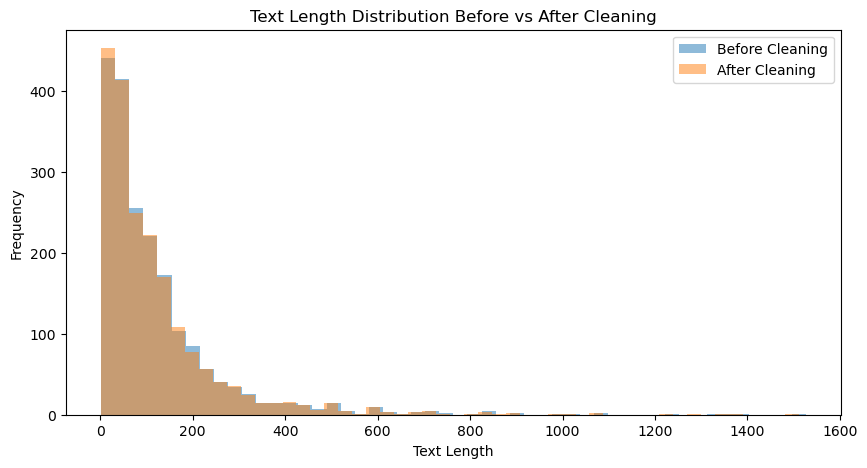

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(train['len_before'], bins=50, alpha=0.5, label='Before Cleaning')
plt.hist(train['len_after'], bins=50, alpha=0.5, label='After Cleaning')

plt.legend()
plt.title("Text Length Distribution Before vs After Cleaning")
plt.xlabel("Text Length")
plt.ylabel("Frequency")

plt.show()